# Overdispersion in Count and Binary Models

## Overview

**Overdispersion** occurs when the observed variance in the data exceeds the variance assumed by the model. For Poisson models, the assumed variance equals the mean. For binomial models, the assumed variance is n·p·(1−p). When real data are more variable, standard errors are underestimated, leading to anticonservative p-values and inflated Type I error.

**Sources of overdispersion:**
- Unobserved heterogeneity (unmeasured confounders)
- Clustering / non-independence of observations
- Excess zeros (zero-inflation)
- Ecological aggregation (species are clumped, not randomly distributed)

**Remedies by severity:**

| Approach | When to use |
|---|---|
| **Quasi-Poisson / quasi-binomial** | Mild overdispersion; adjust SEs only |
| **Negative binomial** | Moderate–severe overdispersion in counts |
| **Beta-binomial** | Overdispersion in proportions |
| **Zero-inflated models** | Excess zeros dominate |
| **Random effects (GLMM)** | Clustering explains overdispersion |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(MASS)          # glm.nb()
library(pscl)          # zeroinfl(), vuong()
library(glmmTMB)       # zero-inflated NB, beta-binomial
library(DHARMa)        # dispersion tests
library(AER)           # dispersiontest()
library(patchwork)

set.seed(42)

n <- 250
over_data <- tibble(
  nitrate    = runif(n, 1, 10),
  water_qual = runif(n, 2, 9),
  mu         = exp(1.5 - 0.2*nitrate + 0.15*water_qual),
  # True distribution: negative binomial (size=1.5 = strong overdispersion)
  count_nb   = rnbinom(n, mu=mu, size=1.5),
  # Zero-inflated: 35% structural zeros
  zi_flag    = rbinom(n, 1, 0.35),
  count_zi   = ifelse(zi_flag==1, 0, rnbinom(n, mu=mu, size=3))
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'MASS' was built under R version 4.4.3"

Attaching package: 'MASS'


The following object is masked from 'p

---

## Detecting Overdispersion

Deviance/df ratio: 3.25 (should be ~1.0; > 1.5 suggests overdispersion)

Dispersion test: z=6.472, p=0.0000 ← significant overdispersion
Estimated overdispersion (alpha): 2.123



	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 3.7965, p-value < 2.2e-16
alternative hypothesis: two.sided



Observed variance: 23.52
Expected (Poisson = mean): 4.24
Variance/mean ratio: 5.55


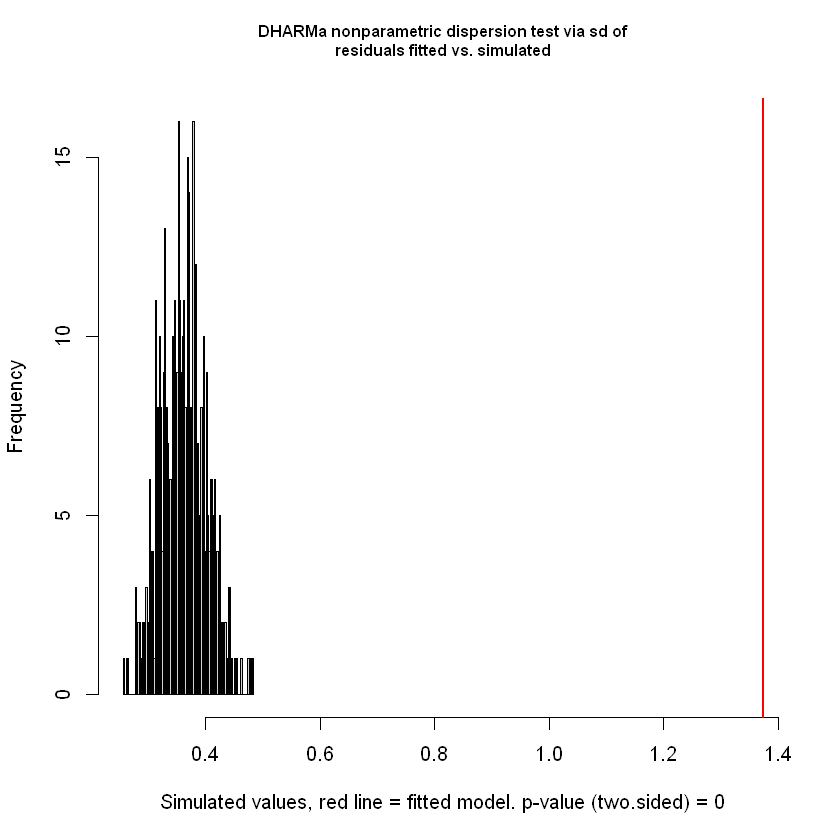

In [2]:
# ── Fit Poisson baseline ──────────────────────────────────────────────────────
m_pois <- glm(count_nb ~ nitrate + water_qual,
              data=over_data, family=poisson)

# ── Quick ratio check: residual deviance / df should be ≈ 1 ──────────────────
disp_ratio <- m_pois$deviance / m_pois$df.residual
cat(sprintf("Deviance/df ratio: %.2f (should be ~1.0; > 1.5 suggests overdispersion)\n",
            disp_ratio))

# ── Formal test: Cameron & Trivedi dispersion test ───────────────────────────
disp_test <- AER::dispersiontest(m_pois, trafo=1)
cat(sprintf("\nDispersion test: z=%.3f, p=%.4f%s\n",
            disp_test$statistic, disp_test$p.value,
            ifelse(disp_test$p.value < 0.05, " ← significant overdispersion", "")))
cat(sprintf("Estimated overdispersion (alpha): %.3f\n", disp_test$estimate))

# ── DHARMa dispersion test ───────────────────────────────────────────────────
sim_res <- DHARMa::simulateResiduals(m_pois, n=500, plot=FALSE)
DHARMa::testDispersion(sim_res)

# ── Observed vs. expected variance ───────────────────────────────────────────
cat(sprintf("\nObserved variance: %.2f\n", var(over_data$count_nb)))
cat(sprintf("Expected (Poisson = mean): %.2f\n", mean(over_data$count_nb)))
cat(sprintf("Variance/mean ratio: %.2f\n", var(over_data$count_nb)/mean(over_data$count_nb)))

---

## Remedies: Quasi-Poisson and Negative Binomial

In [4]:
# ── Quasi-Poisson: same coefficients, inflated SEs ───────────────────────────
m_quasi <- glm(count_nb ~ nitrate + water_qual,
               data = over_data, family = quasipoisson)

# ── Negative binomial: estimates dispersion parameter theta ──────────────────
m_nb <- MASS::glm.nb(count_nb ~ nitrate + water_qual, data = over_data)
cat(sprintf("NB theta (dispersion): %.3f (smaller = more overdispersed)\n",
            m_nb$theta))

# ── Compare SE inflation across models ───────────────────────────────────────
se_compare <- bind_rows(
  broom::tidy(m_pois)  %>% dplyr::mutate(model = "Poisson"),
  broom::tidy(m_quasi) %>% dplyr::mutate(model = "Quasi-Poisson"),
  broom::tidy(m_nb)    %>% dplyr::mutate(model = "Neg. Binomial")
) %>%
  dplyr::filter(term != "(Intercept)") %>%
  dplyr::select(model, term, estimate, std.error, p.value) %>%
  dplyr::mutate(dplyr::across(where(is.numeric), ~round(.x, 4)))

print(se_compare)
# Key insight: Quasi-Poisson SEs are inflated proportionally;
# NB estimates both the mean model AND the dispersion;
# Poisson SEs are too small — p-values anticonservative

NB theta (dispersion): 1.706 (smaller = more overdispersed)
# A tibble: 6 × 5
  model         term       estimate std.error p.value
  <chr>         <chr>         <dbl>     <dbl>   <dbl>
1 Poisson       nitrate      -0.207    0.0128       0
2 Poisson       water_qual    0.141    0.0149       0
3 Quasi-Poisson nitrate      -0.207    0.0227       0
4 Quasi-Poisson water_qual    0.141    0.0264       0
5 Neg. Binomial nitrate      -0.204    0.0232       0
6 Neg. Binomial water_qual    0.144    0.0289       0


---

## Zero-Inflated Models

Zero-inflation test on standard Poisson:



	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 2.8096, p-value < 2.2e-16
alternative hypothesis: two.sided


Vuong Non-Nested Hypothesis Test-Statistic: 
(test-statistic is asymptotically distributed N(0,1) under the
 null that the models are indistinguishible)
-------------------------------------------------------------
              Vuong z-statistic             H_A    p-value
Raw                    3.348480 model1 > model2 0.00040628
AIC-corrected          2.971822 model1 > model2 0.00148019
BIC-corrected          2.308630 model1 > model2 0.01048206

Vuong test (ZINB vs. NB):
NULL

AIC: Poisson=1398.0 | NB=1005.2 | ZIP=1018.0 | ZINB=973.6


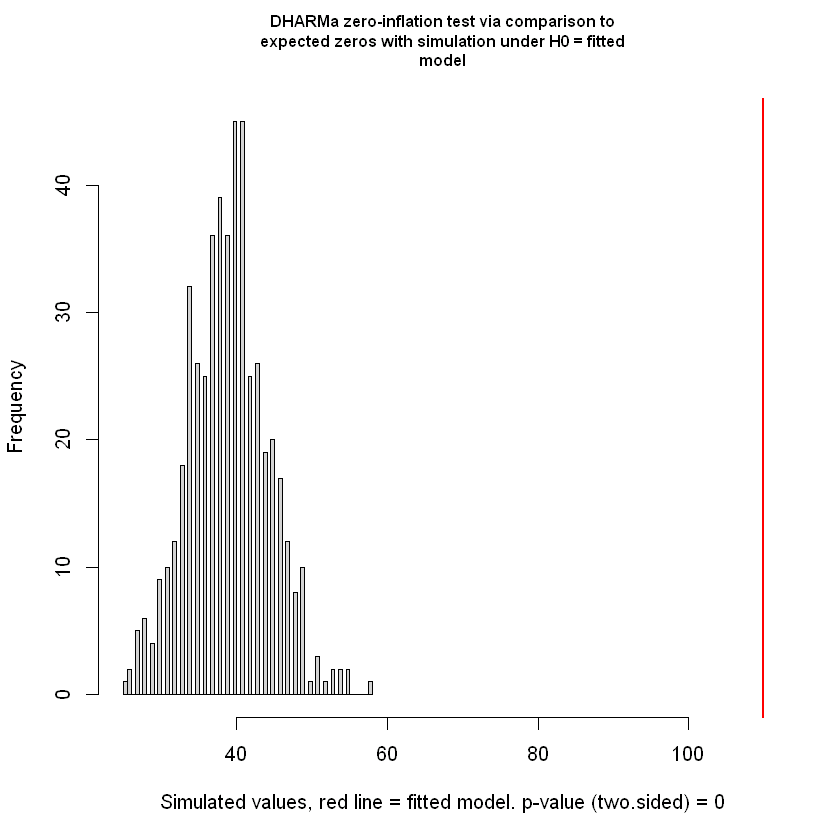

In [5]:
# Zero-inflated models have two components:
# 1. A binary model for structural zeros (species truly absent)
# 2. A count model for the positive counts (and some sampling zeros)

# ── Test for excess zeros ─────────────────────────────────────────────────────
m_pois_zi <- glm(count_zi ~ nitrate + water_qual,
                 data=over_data, family=poisson)
sim_zi <- DHARMa::simulateResiduals(m_pois_zi, n=500, plot=FALSE)
cat("Zero-inflation test on standard Poisson:\n")
DHARMa::testZeroInflation(sim_zi)

# ── Zero-inflated Poisson ─────────────────────────────────────────────────────
m_zip <- pscl::zeroinfl(
  count_zi ~ nitrate + water_qual | nitrate,  # count | zero-inflation part
  data   = over_data,
  dist   = "poisson"
)

# ── Zero-inflated NB (most flexible) ─────────────────────────────────────────
m_zinb <- pscl::zeroinfl(
  count_zi ~ nitrate + water_qual | nitrate,
  data = over_data,
  dist = "negbin"
)

# Compare with Vuong test: is zero-inflation needed?
m_nb_zi <- MASS::glm.nb(count_zi ~ nitrate + water_qual, data=over_data)
vuong_result <- pscl::vuong(m_zinb, m_nb_zi)
cat("\nVuong test (ZINB vs. NB):\n")
print(vuong_result)
# Positive z: ZINB better; negative z: NB better; |z| > 2: significant

# AIC comparison
cat(sprintf("\nAIC: Poisson=%.1f | NB=%.1f | ZIP=%.1f | ZINB=%.1f\n",
            AIC(m_pois_zi), AIC(m_nb_zi), AIC(m_zip), AIC(m_zinb)))

---

## Common Pitfalls

**1. Ignoring overdispersion in Poisson models**  
A Poisson model with overdispersion produces standard errors that are too small — sometimes by a factor of 3–5× — leading to wildly anticonservative p-values. The deviance/df ratio is a fast first check. Always apply it before interpreting any Poisson regression.

**2. Choosing quasi-Poisson vs. negative binomial without understanding the difference**  
Quasi-Poisson estimates a single dispersion scalar and applies it uniformly. Negative binomial explicitly models the variance-mean relationship (variance = μ + μ²/θ) and produces proper likelihood-based model comparisons. Use quasi-Poisson when interpretability is primary and likelihood-based comparison isn't needed; use NB when comparing models with AIC or testing nested models with likelihood ratio tests.

**3. Defaulting to zero-inflation when the issue is overdispersion**  
Many datasets with many zeros are not zero-inflated — they are just overdispersed, and the negative binomial fits perfectly. Always test with DHARMa `testZeroInflation()` before adding a zero-inflation component. An unnecessary zero-inflation component adds parameters and complicates interpretation.

**4. Interpreting zero-inflation model coefficients without separating the two components**  
Zero-inflated models have two sets of coefficients: the count-model coefficients (effect on mean count, given not a structural zero) and the zero-inflation coefficients (effect on probability of being a structural zero). A predictor can have a positive coefficient in the count model and a positive effect on zero-inflation simultaneously — meaning it increases counts among non-zero sites but also increases the probability of the site being a structural zero. Report both components.

**5. Using quasi-Poisson with AIC**  
Quasi-likelihood models do not have a proper likelihood, so AIC is not defined for them. Do not use `AIC()` on a `quasipoisson` model — R will warn but still return a value, which is meaningless. Use negative binomial for AIC-based comparison; use F-tests or QIC for quasi-likelihood model comparison.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*